# Load the Libraries

In [34]:
# === System & Utility Imports === #
import os
import sys
import subprocess
import importlib
import math

# === Data Handling === #
import numpy as np
import pandas as pd
import polars as pl
import h5py

# === Visualization === #
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# === Scikit-Learn === #
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer
)

# === PyTorch === #
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchinfo import summary

# === Misc === #
from enum import Enum
from numpy.lib import recfunctions as rfn

# === Install required packages if missing === #
result = subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "h5py", "pandas", "numpy", "torch", "torch_optimizer",
     "polars", "matplotlib", "scikit-learn", "torchinfo", "torchsummary"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

if result.returncode != 0:
    print("Package installation failed.")

# === Custom Helper Module === #
import helper
importlib.reload(helper)  # Ensure helper module is reloaded and up to date

# Class holding enums for the possible indices of the metadata
class MetadataIndex(Enum):
    # EVENT_NUMBER = 0 No need to assing this 
    OMEGA = 1
    MZ_RECO = 2
    MZ_TRUTH = 3
    MMC_MZ = 4
    OPENING_ANGLE = 5
    LEP_MET_ANGLE_SIGNED = 6
    IS_MET_INSIDE = 7
    IS_EVENT_TPG_HADEL = 8
    TAU_GOOD_ID = 9
    TAU_GOOD_N_TRACKS = 10
    TAU_NN_DECAY = 11
    THREE_BODY_TRAN_MASS = 12
    M3_STAR = 13

# Read the Inputs

In [35]:
files = [
    '../../../H5Dumper/VBF_Ztautau_Sherpa2211_700360_mc20a_fullsim.h5',
    '../../../H5Dumper/VBF_Ztautau_Sherpa2211_700360_mc20d_fullsim.h5',
    '../../../H5Dumper/VBF_Ztautau_Sherpa2211_700360_mc20e_fullsim.h5',
    '../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20a_fullsim.h5',
    '../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20d_fullsim.h5',
    '../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20e_fullsim.h5',
]

# Reading the input files and deleting any with invalid Missing-Mass-Calculator values
signal_inputs, metadata_inputs, input_keys_dict = helper.load_multiple_h5(files)
signal_inputs = np.delete(signal_inputs, np.where(metadata_inputs[:, MetadataIndex.MMC_MZ.value] == 0), axis=0)
metadata_inputs = np.delete(metadata_inputs, np.where(metadata_inputs[:, MetadataIndex.MMC_MZ.value] == 0), axis=0)

print(signal_inputs.shape)
print(metadata_inputs.shape)

# Print the available columns to be read from the signal and metadata
print(f'Particle input Cols: {input_keys_dict}')
with h5py.File(files[0], 'r') as file:
    columns = [name.decode() for name in file['METADATA']['EVENT_DATA'].attrs['columns']]
    print(f'Metadata Cols: {columns}')

(194421, 35, 7)
(194421, 14)
Particle input Cols: {'e': 0, 'eta': 1, 'phi': 2, 'pt': 3, 'btag': 4, 'charge': 5, 'type': 6}
Metadata Cols: ['ljet_GN2_quantile_NOSYS', 'Lep_charge', 'tau_good_charge_NOSYS', 'met_tight_met_NOSYS', 'met_tight_phi_NOSYS', 'eventNumber', 'omega_NOSYS', 'MZ_NOSYS', 'MATCHED_tau_tau_MZ', 'mmc_mlm_mass_NOSYS', 'opening_angle_NOSYS', 'lep_MET_phi_signed_NOSYS', 'isMissingETInside_NOSYS', 'event_topology_NOSYS', 'tau_good_ID_quantile_NOSYS', 'tau_good_n_tracks_NOSYS', 'tau_NNDecayMode', 'ThreeBodyTranMass_NOSYS', 'M3Star_NOSYS']


# Data Exploration

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def compare_distribution_tails(data, left_tail_ind, right_tail_ind, x_range=None, variable_name='', n_bins=40, metadata=False):
    plt.figure(figsize=(10, 6), dpi=100)
    
    # Extract the variable column if given
    if variable_name != '' and not metadata:
        feature_index  = input_keys_dict[variable_name[:-1]]  # everything except last char
        particle_index = int(variable_name[-1])
        array = data[:, particle_index, feature_index]
    else:
        array = data
    
    # Identify the three regions
    left_tail  = array[left_tail_ind]
    right_tail = array[right_tail_ind]
    
    # Peak = all indices not in left or right
    all_idx = np.arange(len(array))
    peak_ind = np.setdiff1d(all_idx, np.concatenate([left_tail_ind, right_tail_ind]))
    peak = array[peak_ind]
    
    # Determine x range if not provided
    if x_range is None:
        x_range_max = np.nanmax(array)
        x_range_min = np.nanmin(array)
        x_range = [x_range_min, x_range_max]
    
    # Plot histograms
    plt.hist(left_tail,  bins=n_bins, range=x_range, histtype='step', label='Left tail',  density=True, color='blue')
    plt.hist(peak,       bins=n_bins, range=x_range, histtype='step', label='Peak',       density=True, color='green')
    plt.hist(right_tail, bins=n_bins, range=x_range, histtype='step', label='Right tail', density=True, color='red')
    
    plt.xlabel(variable_name)
    plt.ylabel('Density')
    plt.title(f'Distribution: {variable_name}')
    plt.legend()
    plt.show()



def obtain_max_n_particles_in_dataset(dataset):

    max_n_particles_per_event = []
    max_n_particles = 0
    for event in range(0,dataset.shape[0]):
        #if (event % 100000 == 0):
            #print('Reading event %d' % event)
            #print('Max number of particles so far = %d' % max_n_particles)
        for particle in range(0,43):
            if np.isnan(dataset[event][particle][0]):
                if max_n_particles < particle:
                    max_n_particles = particle+1
                max_n_particles_per_event.append(particle)
                break

    return max_n_particles, max_n_particles_per_event

In [37]:
max_n_particles_signal, n_particles_signal_dist = obtain_max_n_particles_in_dataset(signal_inputs)
print('max_particles_signal = ', max_n_particles_signal)

max_particles_signal =  27


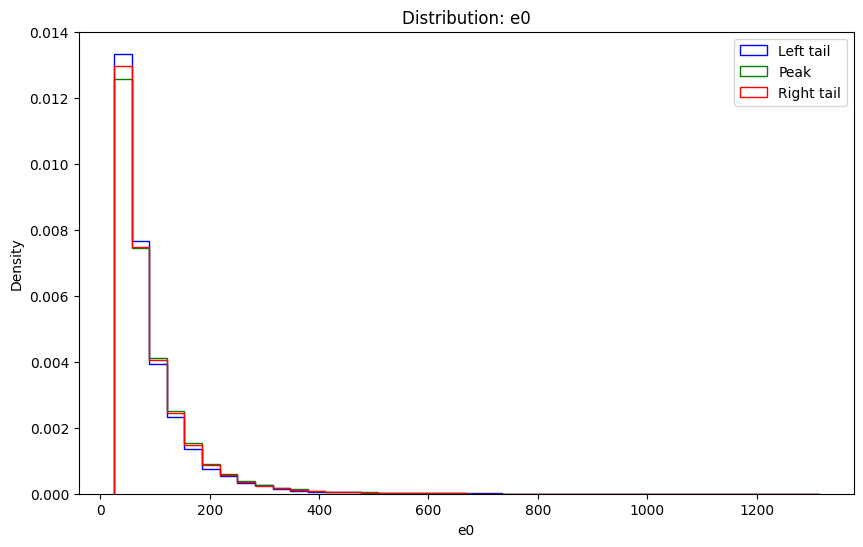

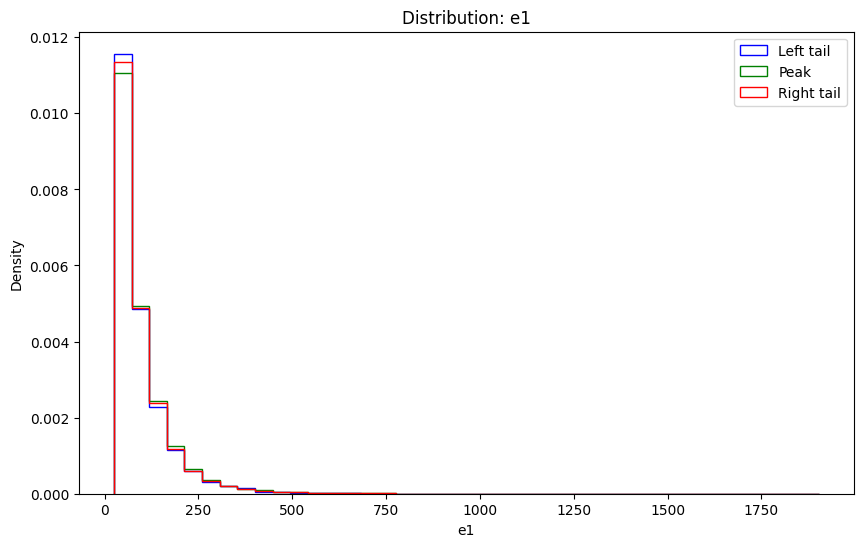

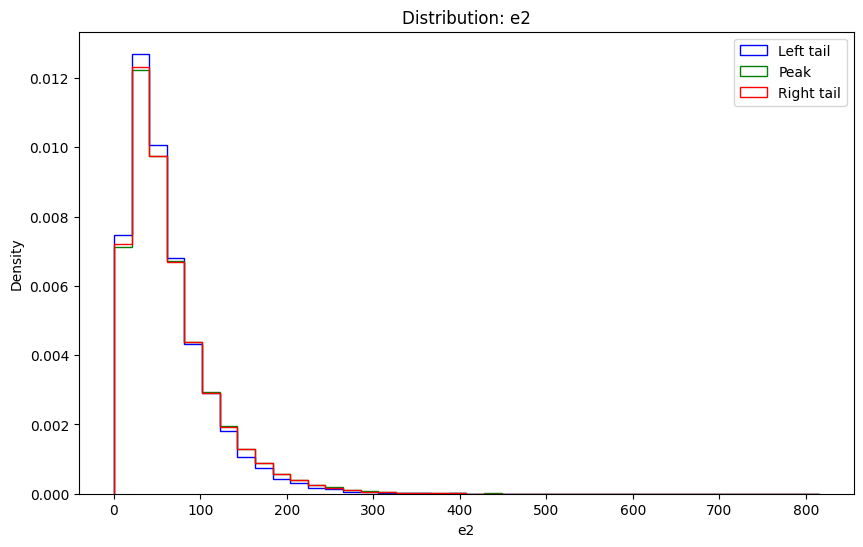

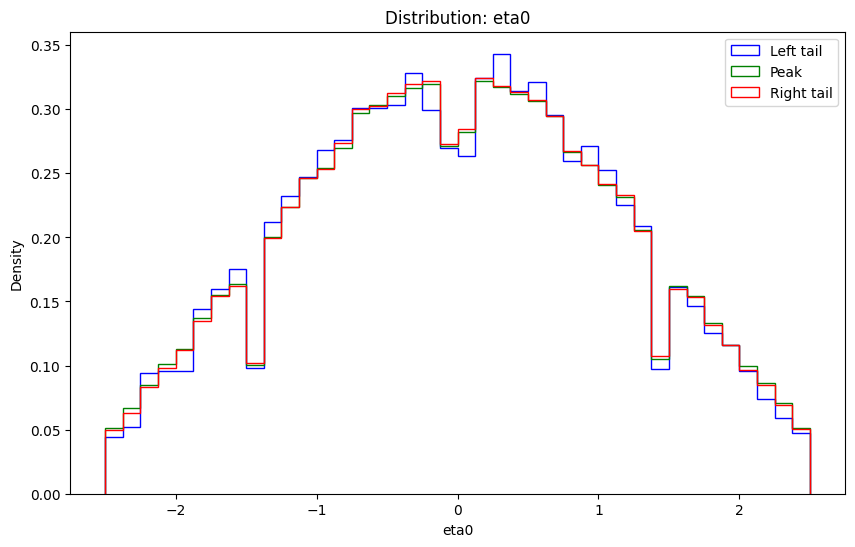

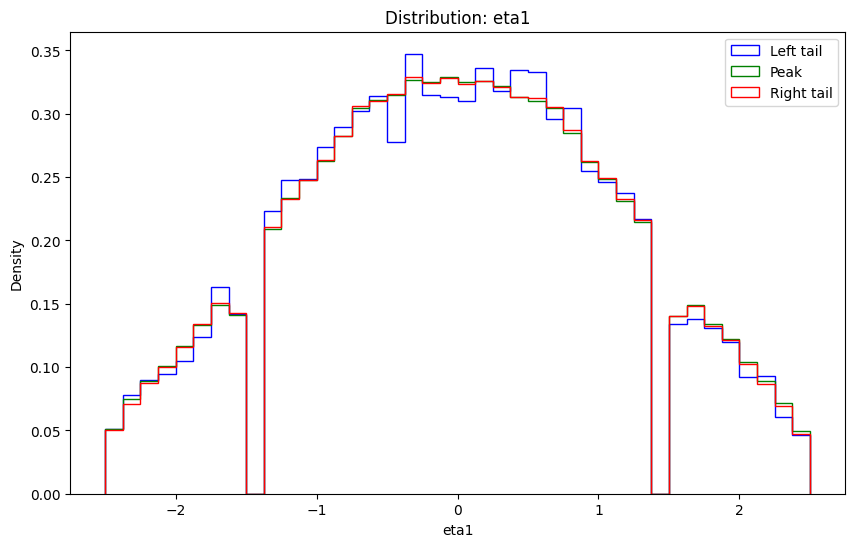

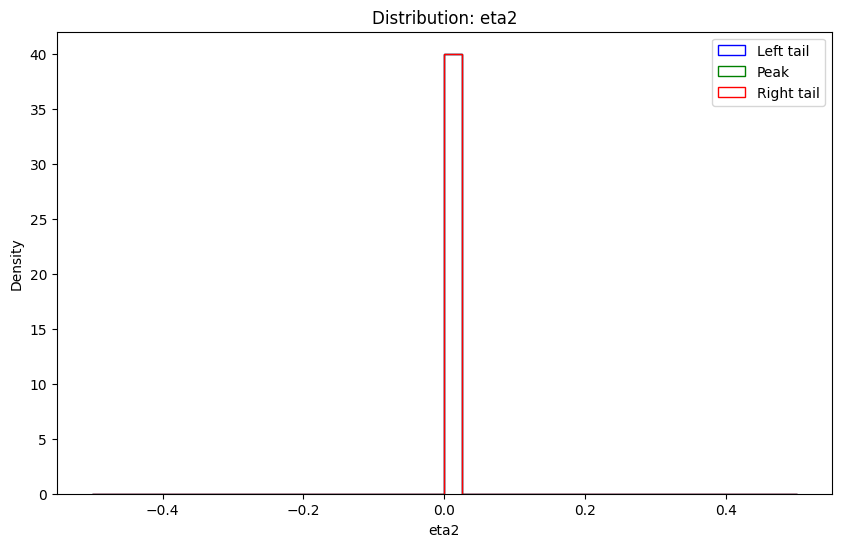

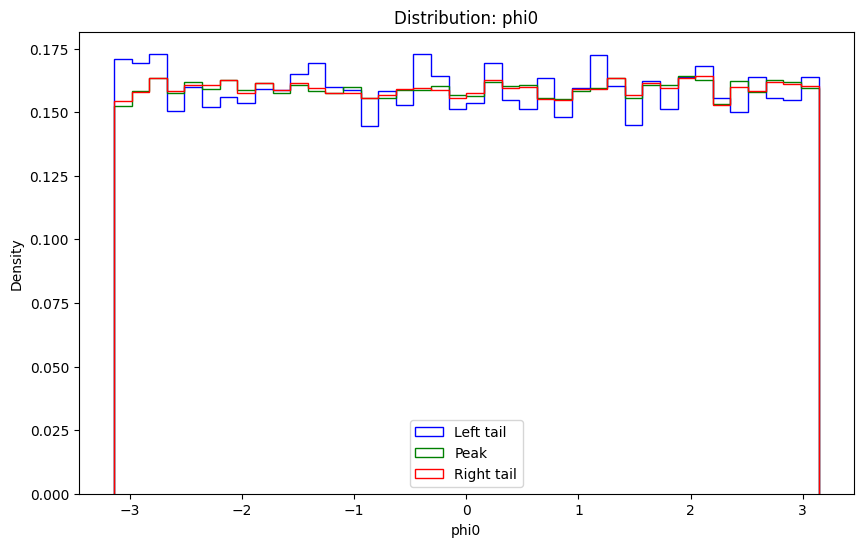

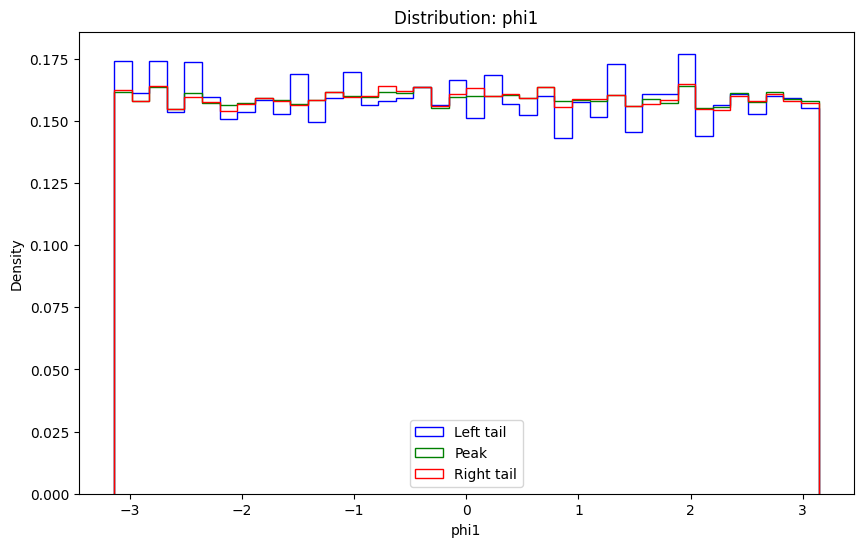

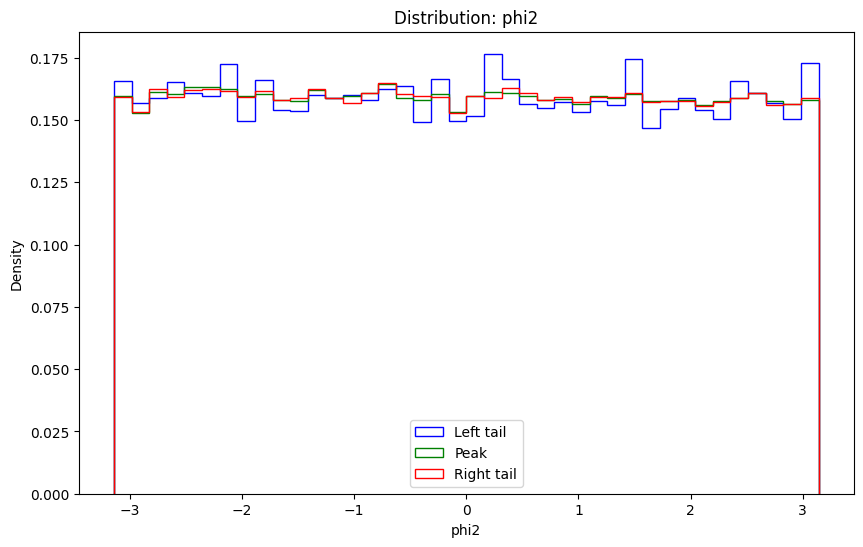

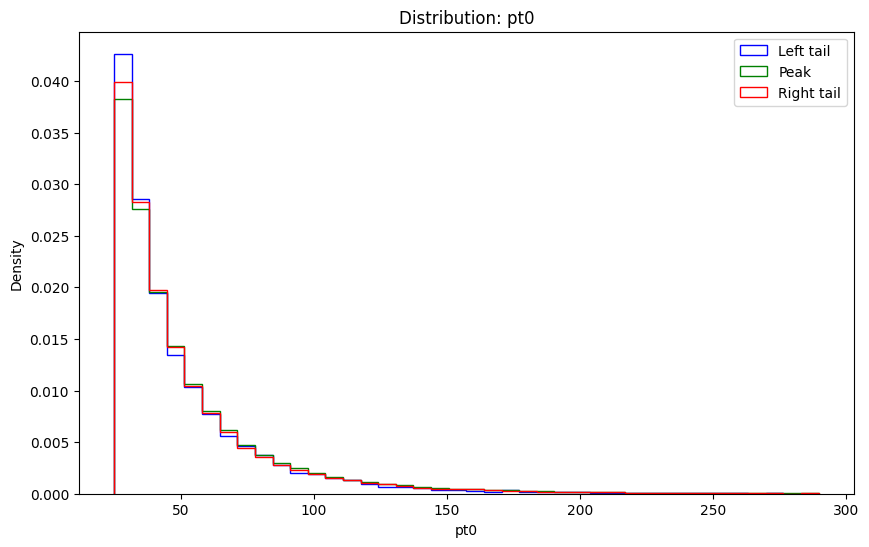

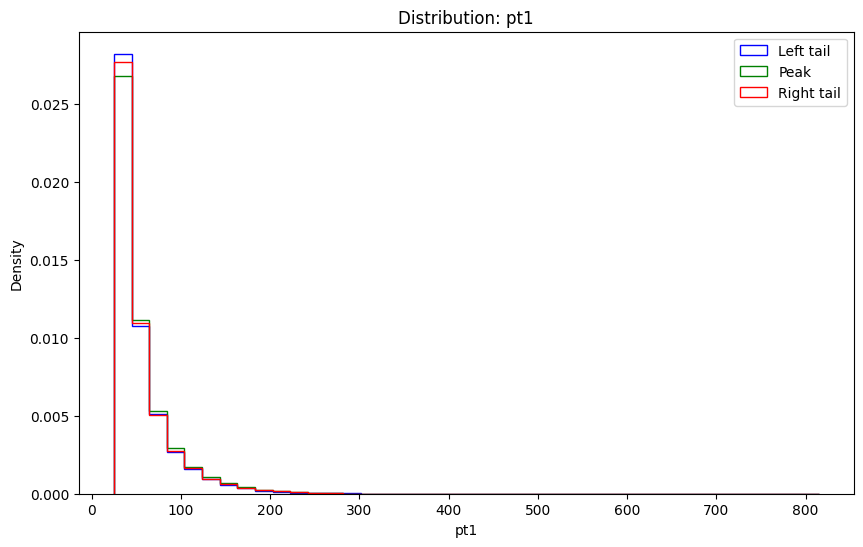

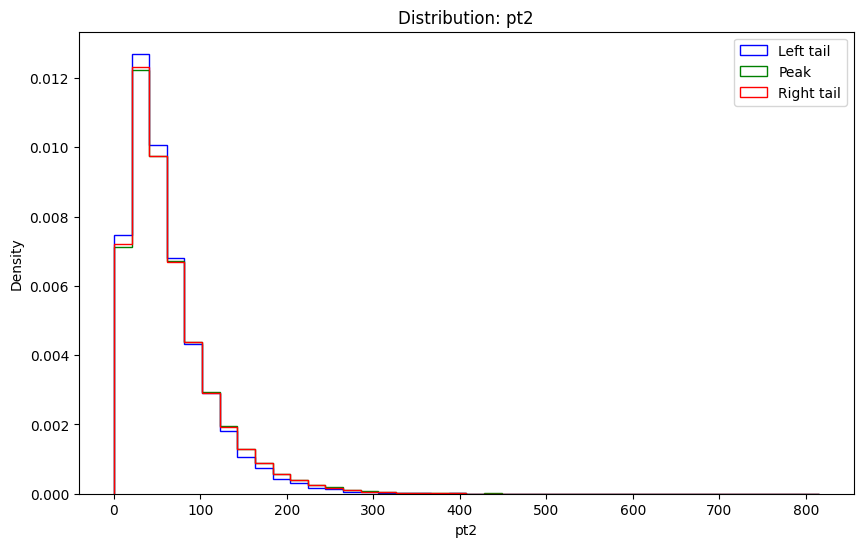

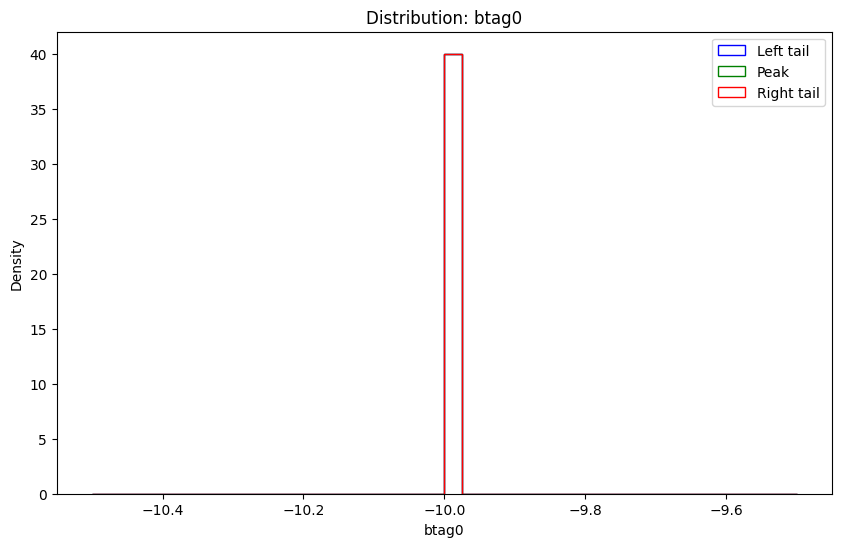

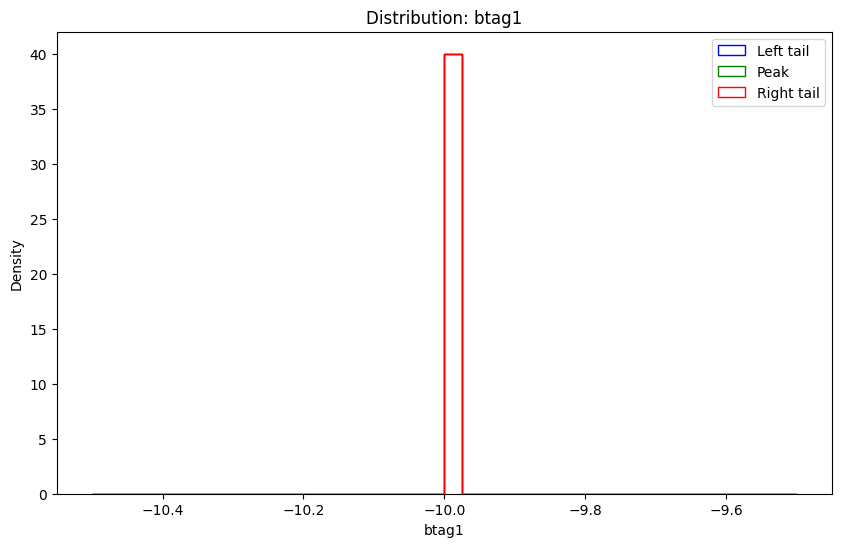

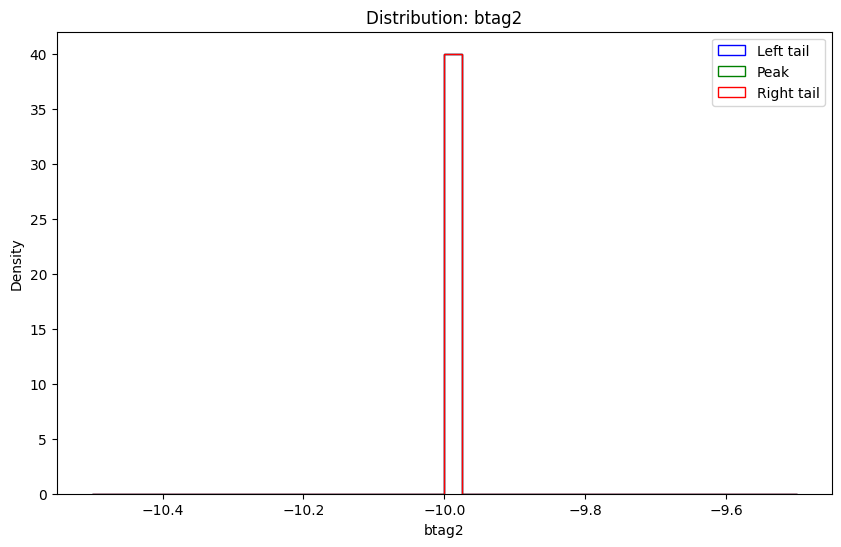

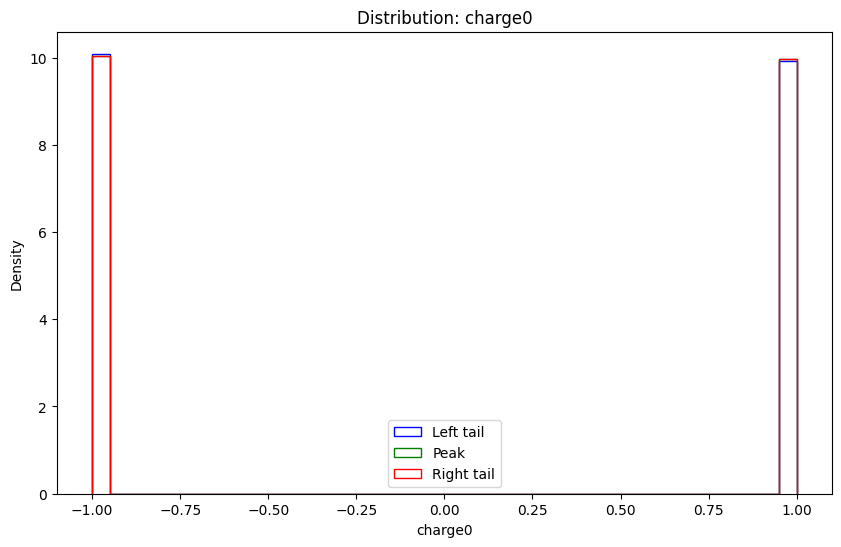

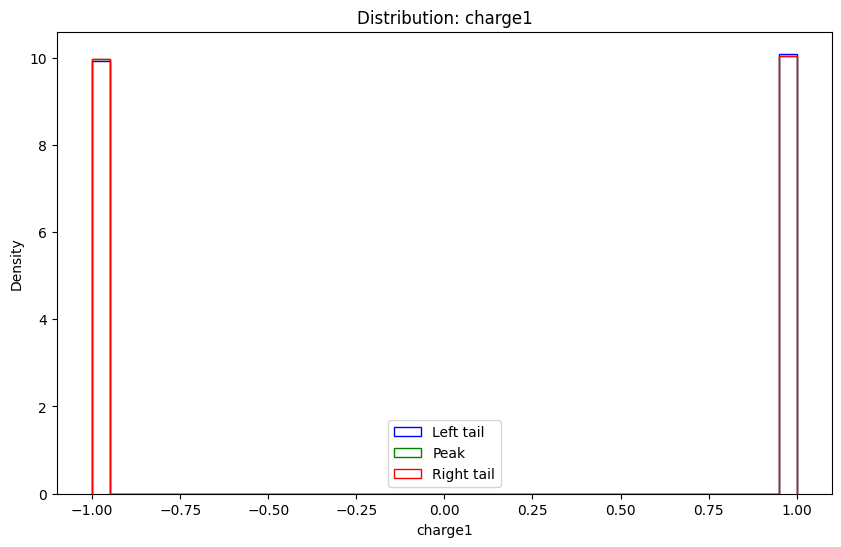

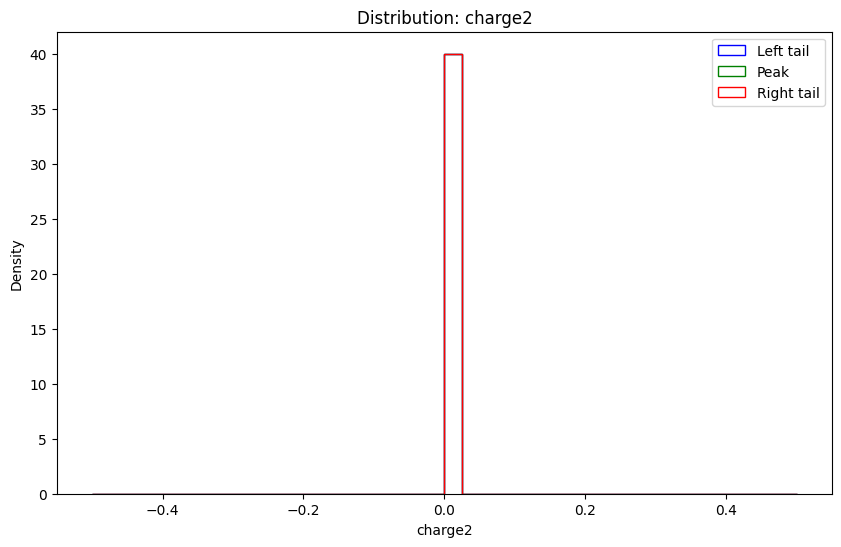

In [38]:
left_tail_ind = metadata_inputs[:, MetadataIndex.MZ_TRUTH.value] < 91.8 - 5
right_tail_ind = metadata_inputs[:, MetadataIndex.MZ_TRUTH.value] < 91.8 + 5

for i in ['e','eta','phi','pt','btag','charge']:
    for j in ['0','1','2']:
        compare_distribution_tails(signal_inputs,left_tail_ind,right_tail_ind,variable_name=i+j)

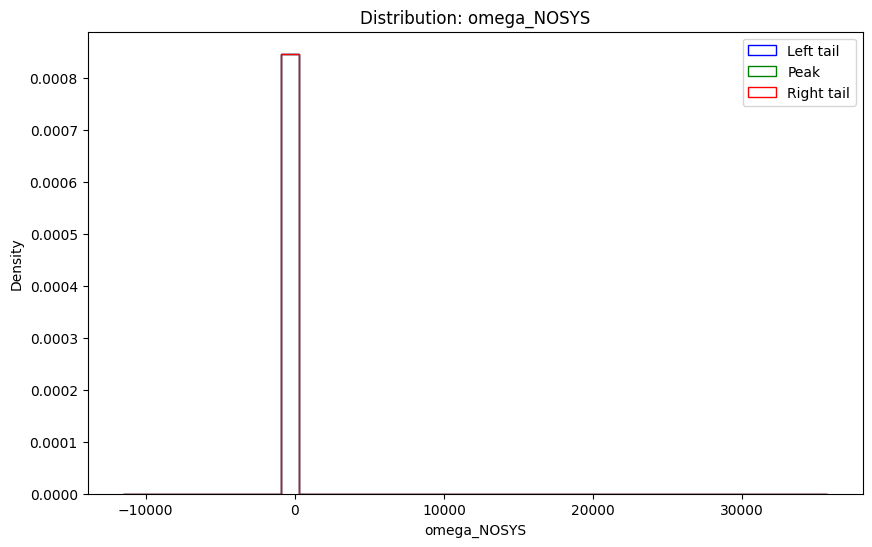

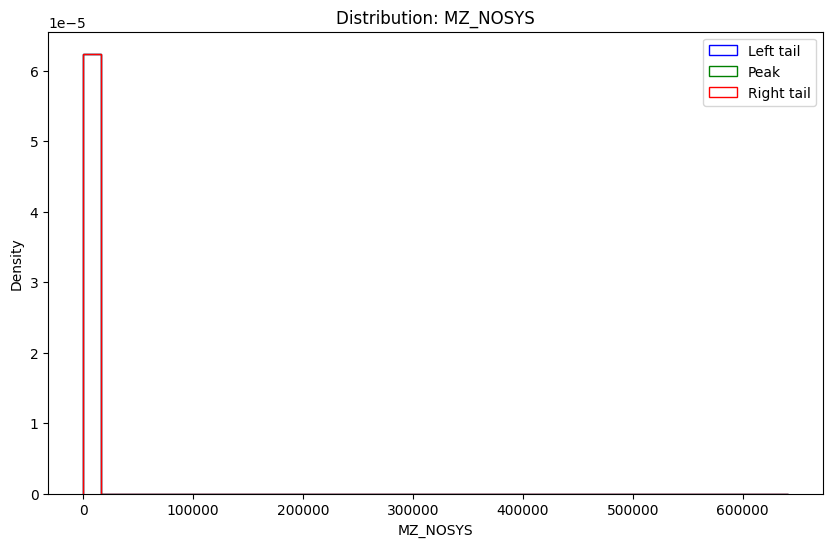

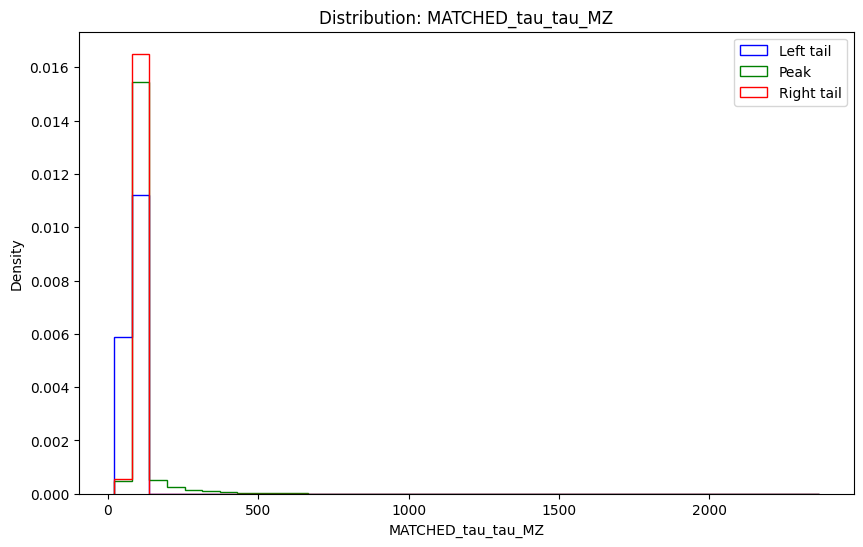

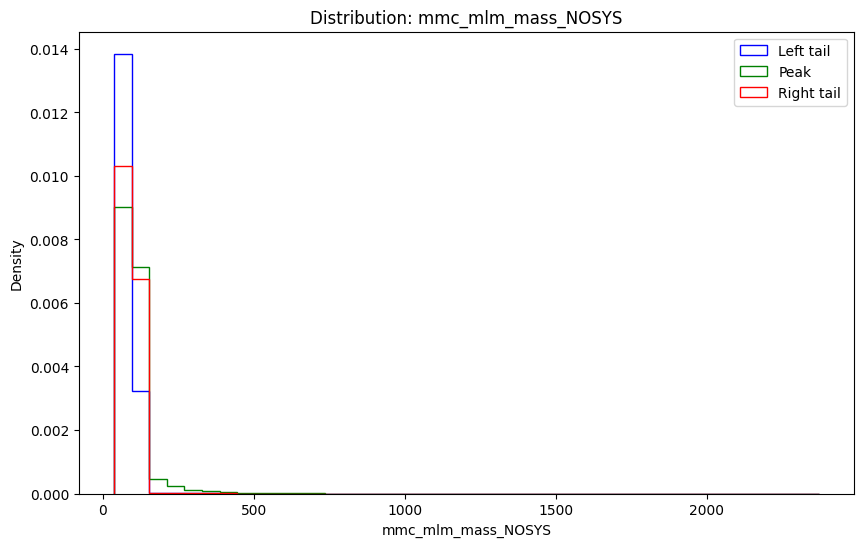

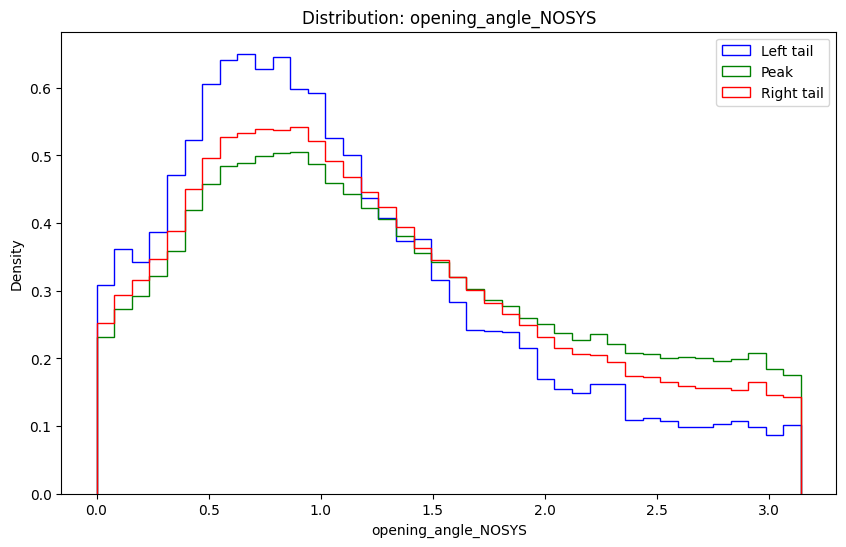

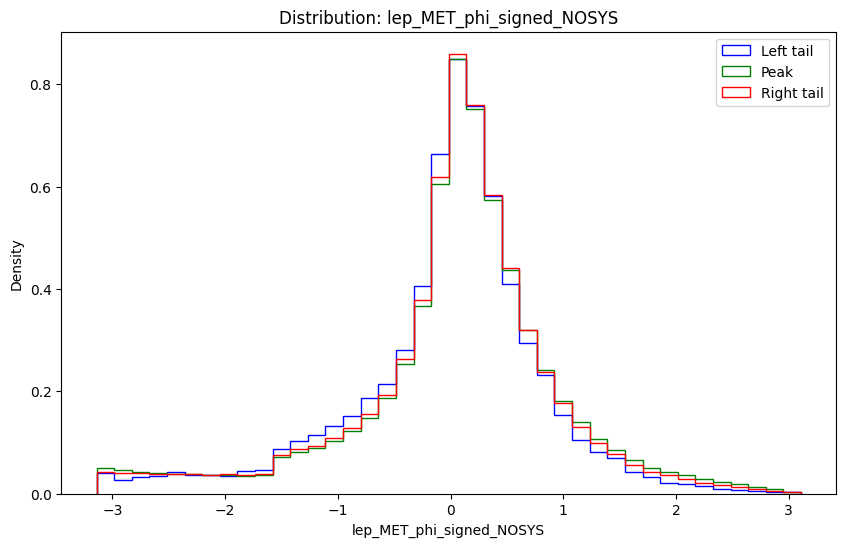

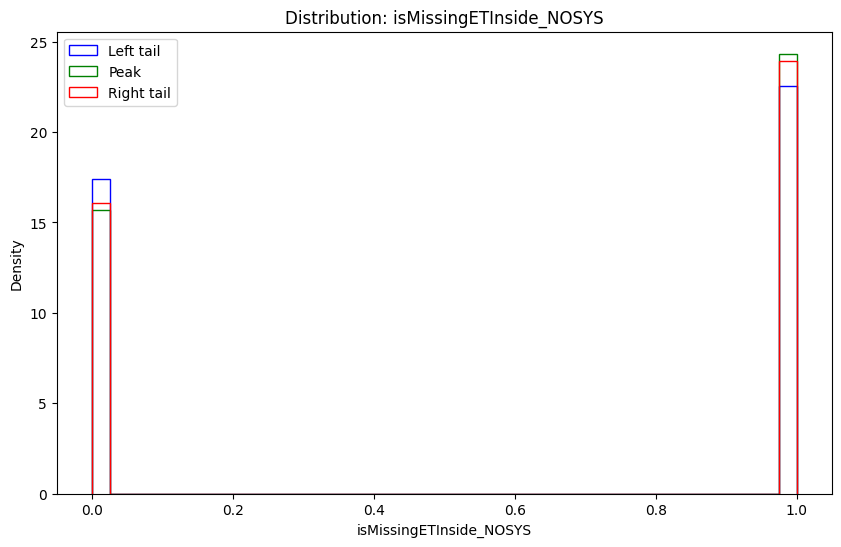

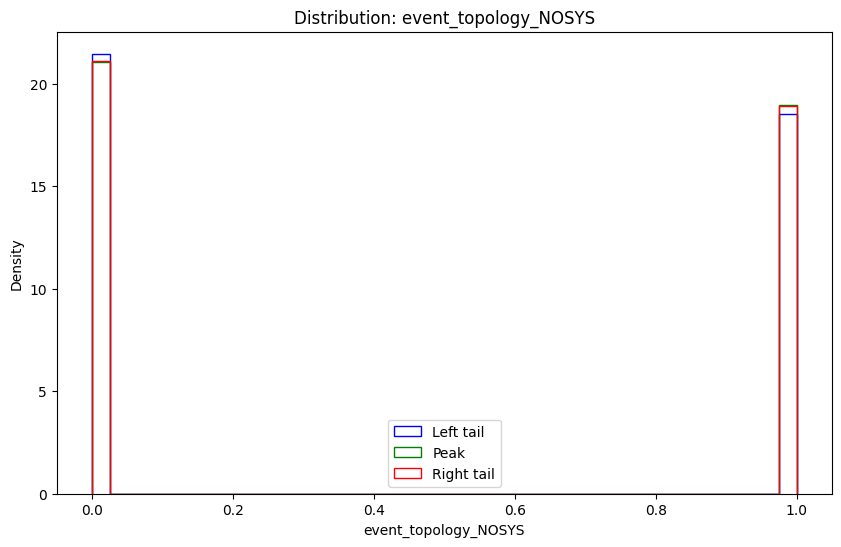

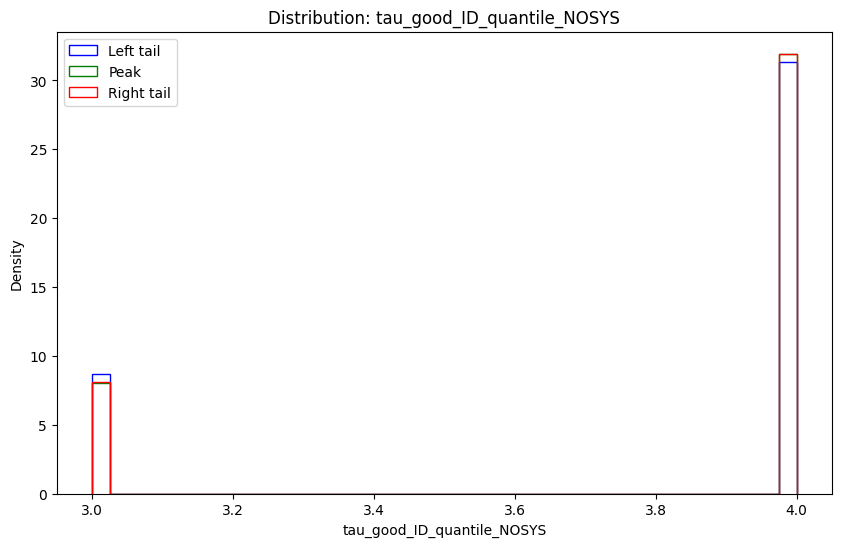

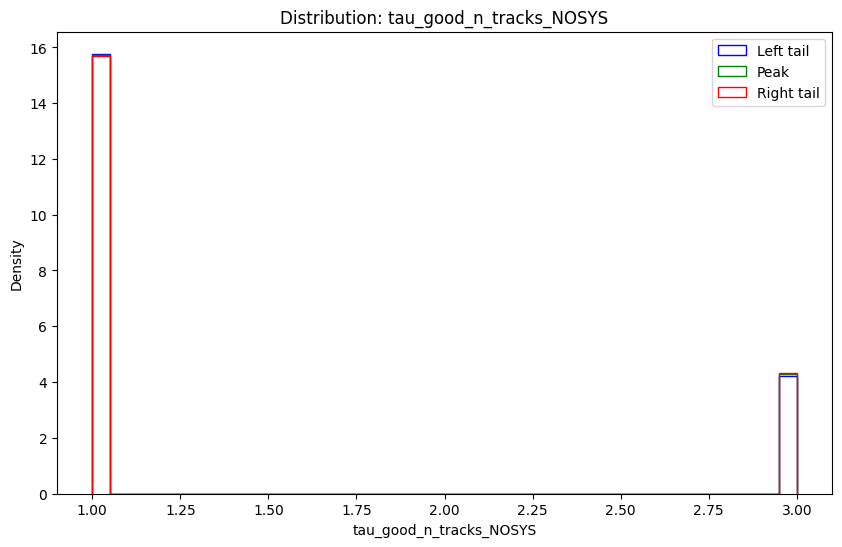

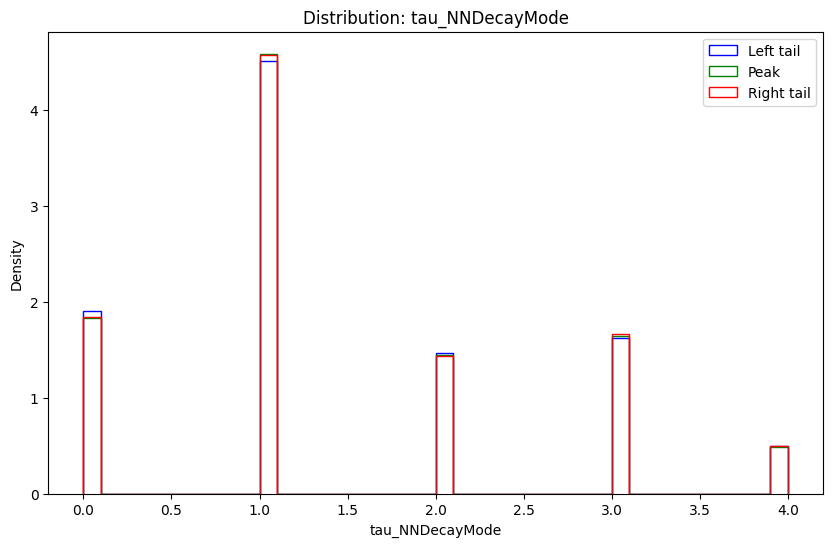

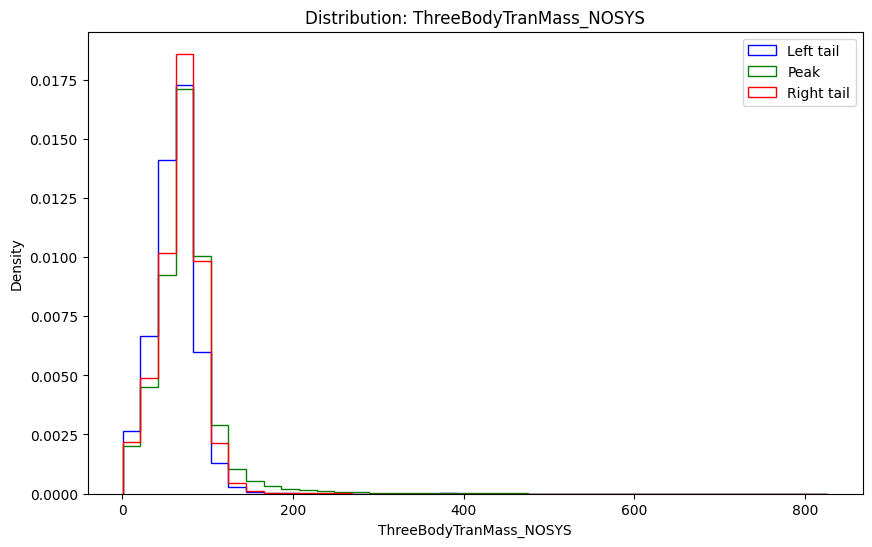

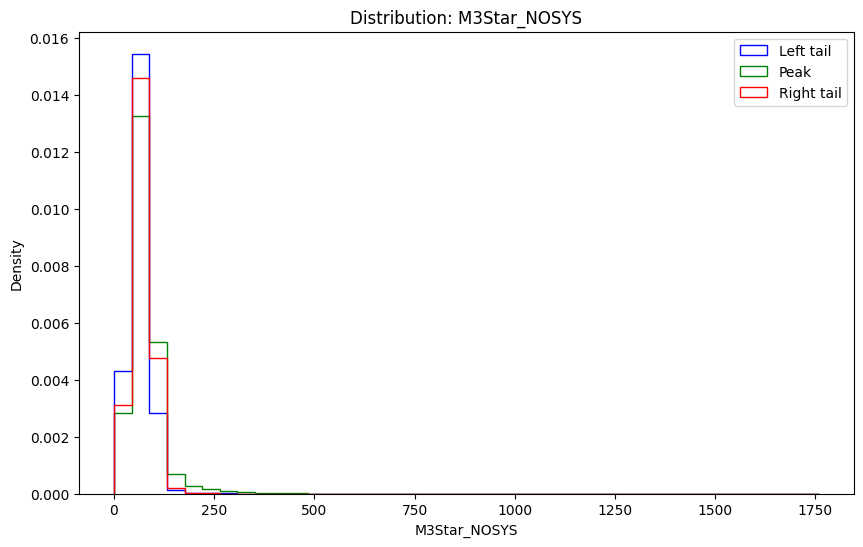

In [39]:
# Skipping the first index containing event details
for i in range(1, len(metadata_inputs[0])):
    compare_distribution_tails(metadata_inputs[:, i],left_tail_ind,right_tail_ind,variable_name=columns[i+ 5], metadata=True)

## Select data to be input in the model

In [40]:
N_PARTICLES = 5 
FEATURES = [0, 1, 3]  # Indices of which particle inputs to use

basic_inputs_filtered = helper.flat_inputs(signal_inputs, N_PARTICLES, FEATURES)
input_data = helper.add_features(basic_inputs_filtered, [
    metadata_inputs[:, MetadataIndex.OPENING_ANGLE.value],  
    metadata_inputs[:, MetadataIndex.LEP_MET_ANGLE_SIGNED.value], 
    metadata_inputs[:, MetadataIndex.MZ_RECO.value]
    ])

target = metadata_inputs[:, MetadataIndex.MZ_TRUTH.value]

The final df shape is: (194421, 18)


In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # and choosing device for training
print(f"Using {device} device")

Using cuda device


In [42]:
indices = np.arange(len(input_data)) # Get original indices

# First split: Train and Temp
X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
    input_data, target, indices, test_size=0.2, random_state=0, shuffle=True
)

# Second split: Val and Test from Temp
X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(
    X_temp, y_temp, idx_temp, test_size=0.5, shuffle=True, random_state=0
)

In [43]:
# do add_mask = True if some variables contain nans
scaler = ColumnTransformer(
    [('E', helper.LogMinMaxScaler(), list(range(0, 5))),
    ('eta', StandardScaler(), list(range(5, 10))),
    ('pt', helper.LogMinMaxScaler(), list(range(10, 15))), 
    ('Opening angle', MinMaxScaler(), [15]), 
    ('LEP_MET_ANGLE_SIGNED', StandardScaler(), [16]), 
    ('MZ_Reco', helper.LogMinMaxScaler(), [17])
    ],
    remainder='passthrough'
)

In [44]:
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(X_train.shape)

(155536, 18)


# Plotting Scaled Data

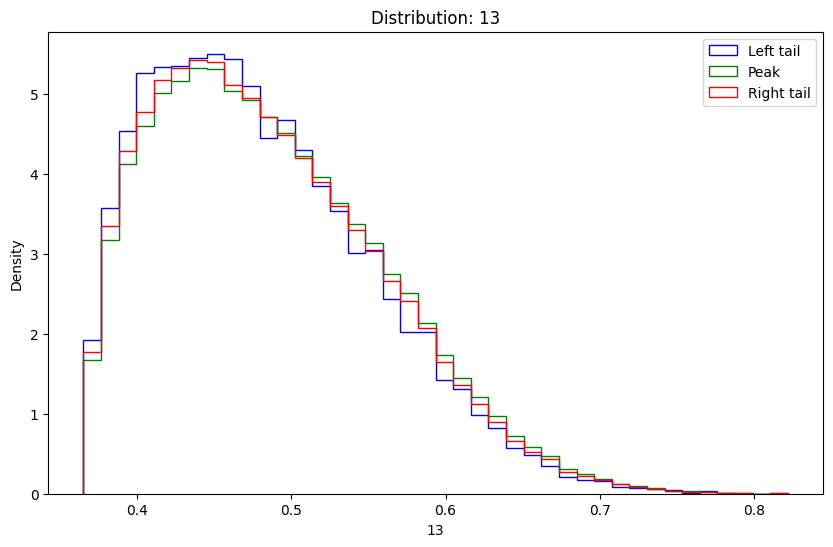

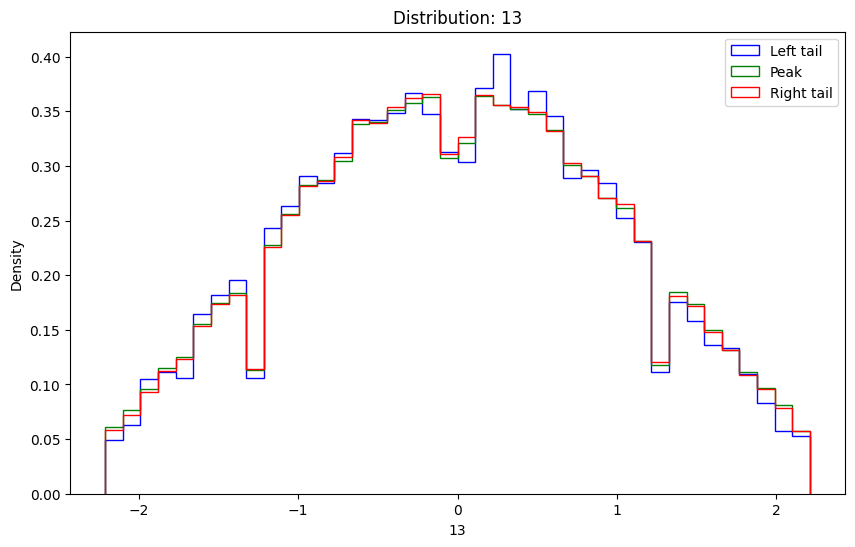

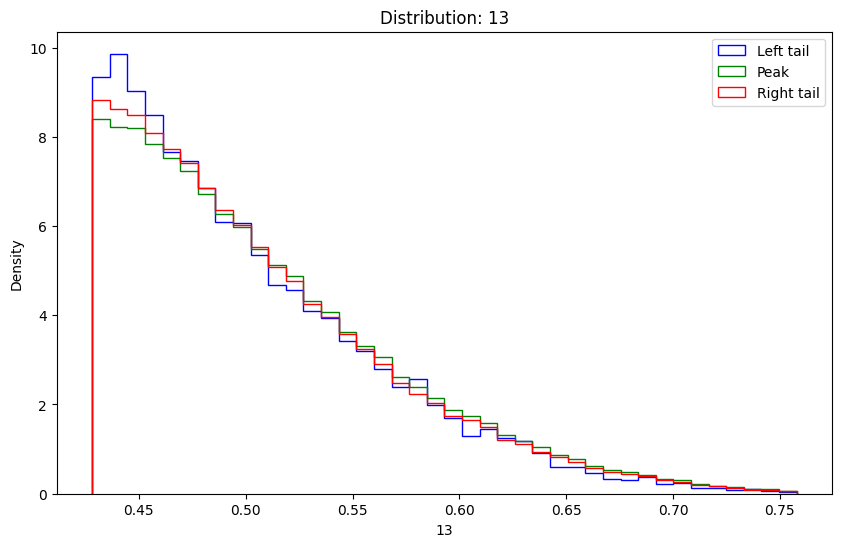

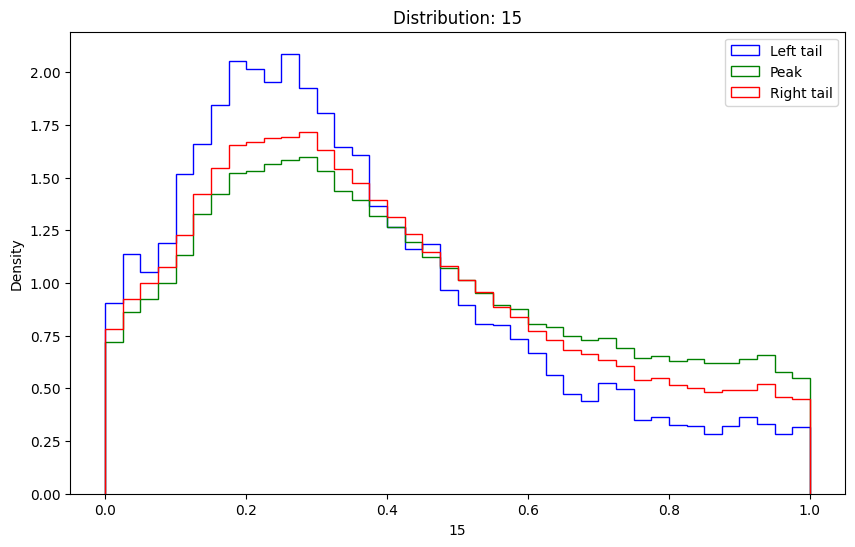

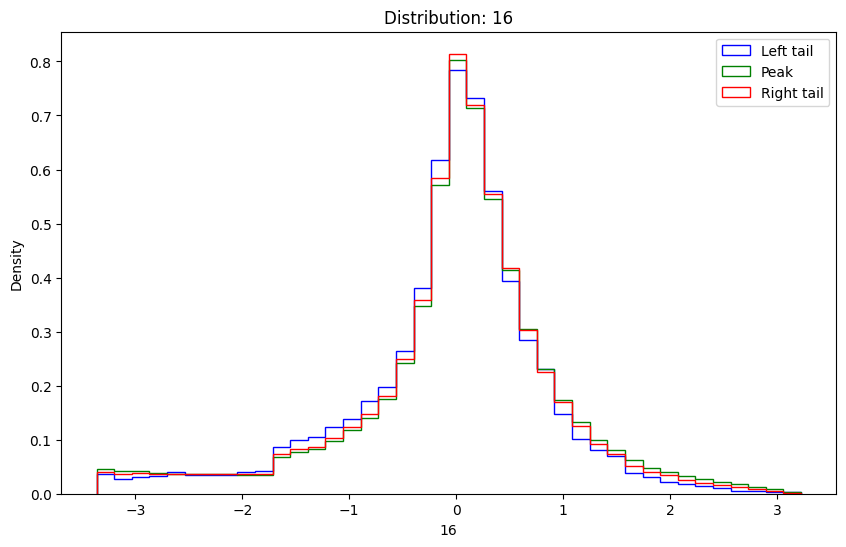

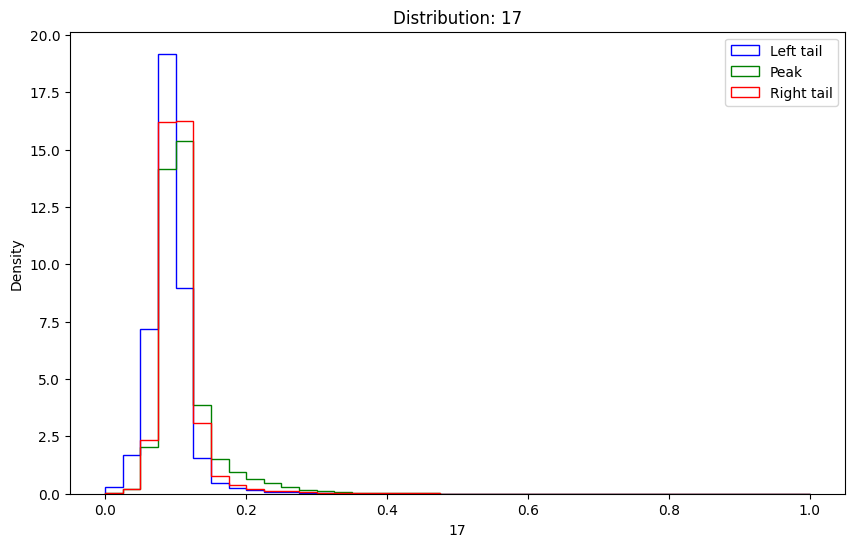

In [45]:
for ind, val in enumerate(['e', 'eta','pt']):
        compare_distribution_tails(X_train[:, ind*N_PARTICLES],left_tail_ind[idx_train],right_tail_ind[idx_train],variable_name=i, metadata=True)

# Skipping the first index containing event details 
for i in range(len(FEATURES) * N_PARTICLES, len(input_data[0, :])):
    compare_distribution_tails(X_train[:, i],left_tail_ind[idx_train],right_tail_ind[idx_train],variable_name=i, metadata=True)

In [46]:
X_train_tensor = torch.nan_to_num(torch.tensor(X_train, dtype=torch.float32), nan=-1)
X_val_tensor   = torch.nan_to_num(torch.tensor(X_val, dtype=torch.float32), nan=-1)
X_test_tensor  = torch.nan_to_num(torch.tensor(X_test, dtype=torch.float32), nan=-1)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.float32)

# Define the model

In [47]:
Hidden_layers = [128, 128]
Drop_out = 0.1
LR = 0.00015
Weight_decay = 0.0
LR_SCHEDULER_PATIENCE = 10

model = helper.SimpleDNN(len(X_train[0]), Hidden_layers, Drop_out).to(device)
summary(model, input_size=(1, len(X_train[0]))) # len(X_train[0]) Is the number of inputs

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=Weight_decay)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=LR_SCHEDULER_PATIENCE)
criterion = nn.SmoothL1Loss(beta=10.0, reduction='mean')

# Train

In [48]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

Num_workers = 15
Train_batch = 512
Eval_batch = 256

# Create DataLoader objects for training, validation, and testing in batches
train_loader = DataLoader(train_dataset, batch_size=Train_batch,  shuffle=True, num_workers=Num_workers, persistent_workers= True, drop_last=True, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=Eval_batch, shuffle=False, num_workers=Num_workers, persistent_workers= True, drop_last=True, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=Eval_batch, shuffle=False, num_workers=Num_workers)

In [49]:
num_epochs = 400
patience = 5
train_losses = []
val_losses = []

best_val_loss = float('inf')
counter = 0
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        inputs_device = inputs.to(device)
        targets_device = targets.to(device)
        outputs = model(inputs_device)
        loss = criterion(outputs.squeeze(), targets_device)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs_device = inputs.to(device)
            targets_device = targets.to(device)
            outputs = model(inputs_device)
            loss = criterion(outputs.squeeze(), targets_device)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # Step the scheduler (assuming ReduceLROnPlateau)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.6f}", end='\r')

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()  # Save the best model weights
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}. Best Val Loss: {best_val_loss:.4f}")
        break

# Load best model weights before testing or saving
model.load_state_dict(best_model_state)

Epoch 323/400, Train Loss: 6.2602, Val Loss: 5.6063, LR: 0.0001500
Early stopping triggered at epoch 323. Best Val Loss: 5.6035


<All keys matched successfully>

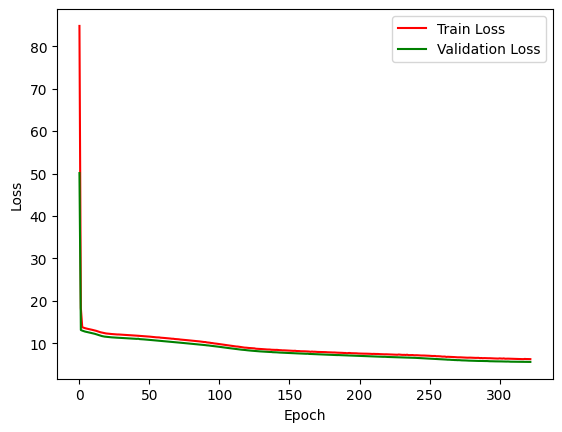

In [50]:
plt.plot(train_losses, label='Train Loss', color='red')
plt.plot(val_losses, label='Validation Loss', color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])

# Save if model good?

In [51]:
save_model = False
if save_model:
    torch.save(model.state_dict(), 'model_weights.pth')

# Evaluating Model Performance

In [52]:
# Force everything on CPU
device = torch.device("cpu")
model = model.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_tensor).squeeze().cpu().numpy() 
    y_true_test = y_test_tensor.cpu().numpy()

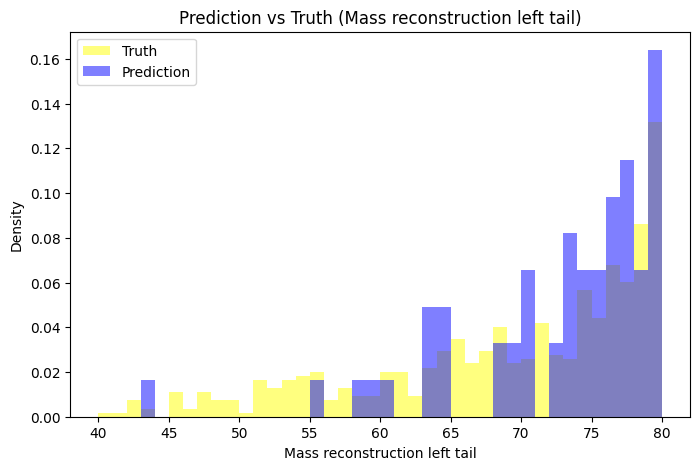

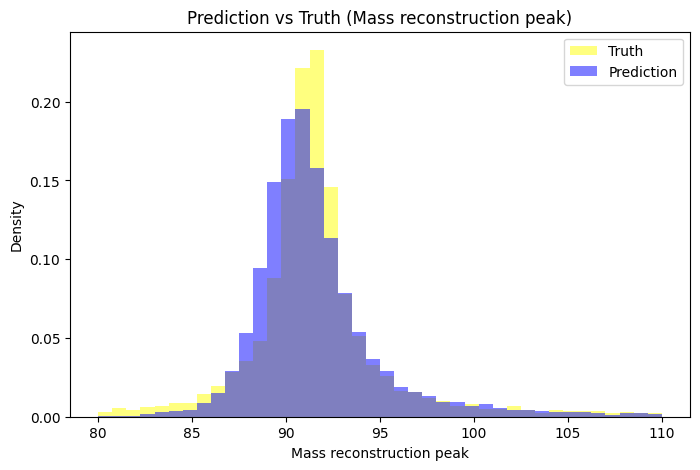

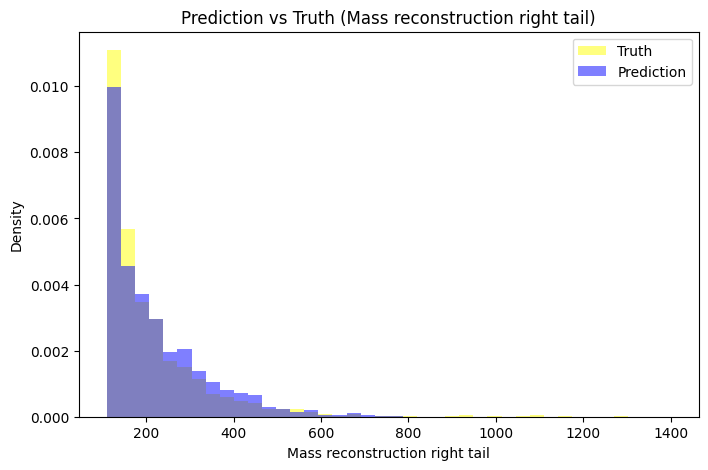

In [53]:
# Plotting prediction vs. truth
def plot_pred_truth(y_pred, y_true, x_range=None, n_bins=40, variable_name="Value"):
    y_pred = np.asarray(y_pred)
    y_true = np.asarray(y_true)

    if x_range is None:
        x_range_min = min(np.nanmin(y_pred), np.nanmin(y_true))
        x_range_max = max(np.nanmax(y_pred), np.nanmax(y_true))
        x_range = [x_range_min, x_range_max]

    plt.figure(figsize=(8, 5), dpi=100)
    plt.hist(y_true, bins=n_bins, range=x_range, density=True, color='yellow', alpha=0.5, label='Truth')
    plt.hist(y_pred, bins=n_bins, range=x_range, density=True, color='blue', alpha=0.5, label='Prediction')
    plt.xlabel(variable_name)
    plt.ylabel('Density')
    plt.title(f'Prediction vs Truth ({variable_name})')
    plt.legend()
    plt.show() 
    
plot_pred_truth(y_pred_test, y_true_test, x_range=[40, 80], n_bins=40, variable_name="Mass reconstruction left tail")
plot_pred_truth(y_pred_test, y_true_test, x_range=[80, 110], n_bins=40, variable_name="Mass reconstruction peak")
plot_pred_truth(y_pred_test, y_true_test, x_range=[110, 1400], n_bins=40, variable_name="Mass reconstruction right tail")

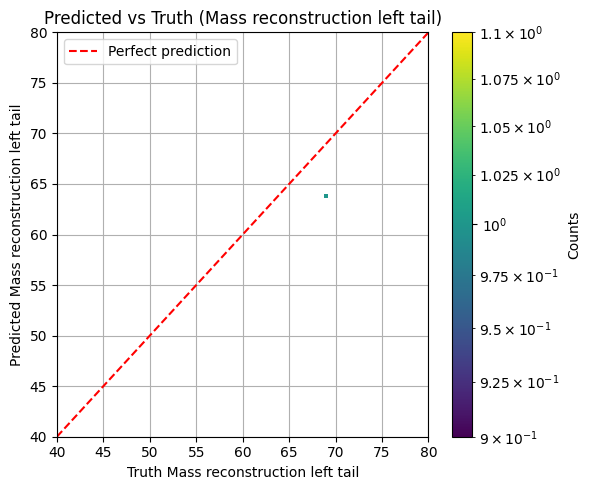

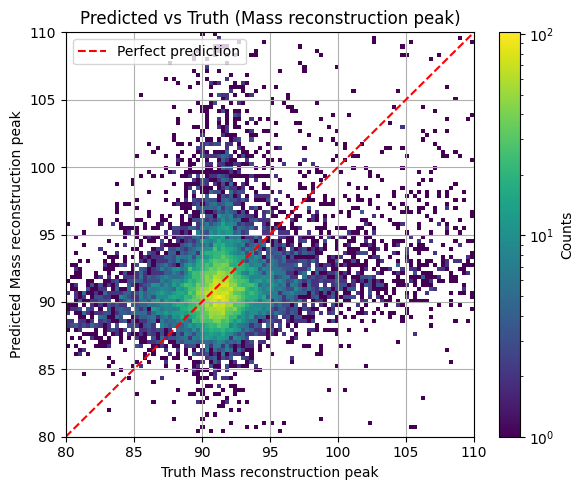

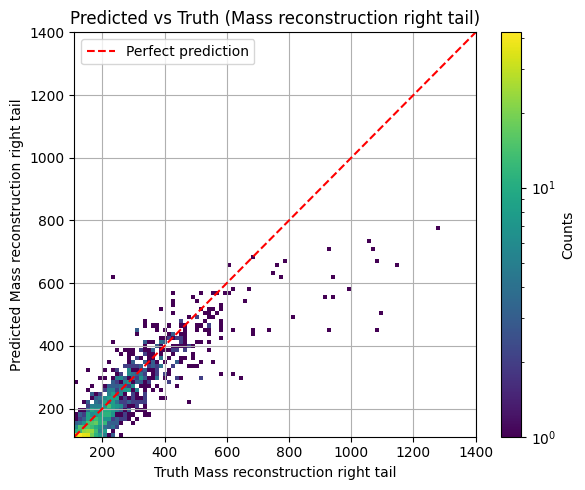

In [54]:
# 2-D Plots
def plot_pred_vs_truth_2d(y_pred, y_true, x_range=None, variable_name="Value", bins=100):
    y_pred = np.asarray(y_pred)
    y_true = np.asarray(y_true)

    if x_range is None:
        min_val = min(np.nanmin(y_pred), np.nanmin(y_true))
        max_val = max(np.nanmax(y_pred), np.nanmax(y_true))
        x_range = [min_val, max_val]

    H, xedges, yedges = np.histogram2d(y_true, y_pred, bins=bins, range=[x_range, x_range])
    H_masked = np.ma.masked_where(H == 0, H) # Mask zeros so they appear as white

    # Create colormap with white for bad values
    cmap = plt.cm.viridis
    cmap.set_bad(color='white')

    plt.figure(figsize=(6, 5), dpi=100)
    mesh = plt.pcolormesh(xedges, yedges, H_masked.T, cmap=cmap, norm=mcolors.LogNorm(vmin=1, vmax=H.max()))
    plt.colorbar(mesh, label='Counts')

    plt.plot(x_range, x_range, 'r--', label='Perfect prediction') # Ideal prediction

    plt.xlabel(f"Truth {variable_name}")
    plt.ylabel(f"Predicted {variable_name}")
    plt.title(f"Predicted vs Truth ({variable_name})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_pred_vs_truth_2d(y_pred_test, y_true_test, x_range=[40, 80], variable_name="Mass reconstruction left tail")
plot_pred_vs_truth_2d(y_pred_test, y_true_test, x_range=[80, 110], variable_name="Mass reconstruction peak")
plot_pred_vs_truth_2d(y_pred_test, y_true_test, x_range=[110, 1400], variable_name="Mass reconstruction right tail")

In [55]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_true_test, y_pred_test)
mae = mean_absolute_error(y_true_test, y_pred_test)
mse = mean_squared_error(y_true_test, y_pred_test)
frac_bias = np.mean((y_pred_test - y_true_test) / y_true_test)

print(f"{'R²':25s}: {r2:.4f}")
print(f"{'Mean Absolute Error':25s}: {mae:.4f}")
print(f"{'Mean Squared Error':25s}: {mse:.4f}")
print(f"{'Mean Fractional Bias':25s}: {frac_bias:.4%}")  # in %

R²                       : 0.8089
Mean Absolute Error      : 8.0643
Mean Squared Error       : 567.6929
Mean Fractional Bias     : 0.2116%


In [56]:
# Ensure numpy arrays
X_test_np = X_test_tensor.cpu().numpy()
y_true_np = y_true_test  # already NumPy in your case
rng = np.random.default_rng(42)

# Get baseline MSE
y_pred_base = model(X_test_tensor).detach().cpu().numpy()
baseline_mse = mean_squared_error(y_true_np, y_pred_base)

print(f"Baseline MSE: {baseline_mse:.6f}")

importances = []
for col in range(X_test_np.shape[1]):
    mse_diffs = []
    for _ in range(5):  # n_repeats
        X_perm = X_test_np.copy()
        rng.shuffle(X_perm[:, col])  # shuffle one feature
        
        y_pred_perm = model(torch.tensor(X_perm, dtype=torch.float32).to(X_test_tensor.device))
        y_pred_perm = y_pred_perm.detach().numpy()
        
        mse_perm = mean_squared_error(y_true_np, y_pred_perm)
        mse_diffs.append(mse_perm - baseline_mse)
    
    importances.append(np.mean(mse_diffs))

# Sort and print
sorted_idx = np.argsort(importances)[::-1]
feature_names = scaler.get_feature_names_out()
print("\nFeature Importances (MSE-based):")
for idx in sorted_idx:
    print(f"{feature_names[idx]:30s}: {importances[idx]:.6f}")

Baseline MSE: 567.692871

Feature Importances (MSE-based):
eta__x5                       : 6171.447754
eta__x6                       : 5877.761719
Opening angle__x15            : 1040.289551
pt__x11                       : 768.739319
pt__x10                       : 481.665833
MZ_Reco__x17                  : 474.732025
pt__x12                       : 129.103119
E__x2                         : 75.382996
LEP_MET_ANGLE_SIGNED__x16     : 13.648584
pt__x13                       : 5.765515
eta__x8                       : 3.670813
E__x4                         : 1.756006
E__x0                         : 0.772131
eta__x7                       : 0.000000
eta__x9                       : -0.328760
E__x1                         : -0.444531
E__x3                         : -1.180078
pt__x14                       : -3.247253
